In [32]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import scipy.stats as stats

In [33]:
# importing
aqi = pd.read_csv("air_quality.csv")
gps = pd.read_csv("gps.csv")
pth = pd.read_csv("pth.csv")
radiation = pd.read_csv("radiation.csv")
spectrum = pd.read_csv("spectrum.csv")

In [34]:
gps.head()

,timestamp,latitude,longitude,accuracy
0,1.776898e+09,37.875980,-122.259010,19.999999
1,1.776898e+09,37.875980,-122.259010,19.999999
2,1.776898e+09,37.875980,-122.259010,142.195014
3,1.776898e+09,37.875981,-122.259011,830.828863
4,1.776898e+09,37.875980,-122.259012,19.994216


In [35]:
gps['readableTime'] = pd.to_datetime(gps['timestamp'], unit='s')
aqi['readableTime'] = pd.to_datetime(aqi['timestamp'], unit='s')
pth['readableTime'] = pd.to_datetime(pth['timestamp'], unit='s')
spectrum['readableTime'] = pd.to_datetime(spectrum['timestamp'], unit='s')
radiation['readableTime'] = pd.to_datetime(radiation['timestamp'], unit='s')
# gps

In [36]:
elapsedGPS = gps['readableTime'].max() - gps['readableTime'].min()
print(f"Elapsed GPS time: {elapsedGPS}")

elapsedAQI = aqi['readableTime'].max() - aqi['readableTime'].min()
print(f"Elapsed AQI time: {elapsedAQI}")

elapsedPTH = pth['readableTime'].max() - pth['readableTime'].min()
print(f"Elapsed PTH time: {elapsedPTH}")

elapsedRad = radiation['readableTime'].max() - radiation['readableTime'].min()
print(f"Elapsed radiation time: {elapsedRad}")

Elapsed GPS time: 0 days 00:16:16.264069558
Elapsed AQI time: 0 days 00:01:37.824878931
Elapsed PTH time: 0 days 00:21:27.213502884
Elapsed radiation time: 0 days 00:20:56.085893631


In [37]:
cutoffPTH = pth['readableTime'].min() + pd.Timedelta(minutes = 5, seconds = 10)
pthNew = pth[pth['readableTime'] >= cutoffPTH].copy()
print(f"New PTH elapsed time: {pthNew['readableTime'].max() - pthNew['readableTime'].min()}")

New PTH elapsed time: 0 days 00:16:16.682926416


In [38]:
gps = gps.sort_values('readableTime')
pthNew = pthNew.sort_values('readableTime')

# 2. Match PTH data to the GPS timestamps
# This will result in exactly 425 rows
GPSPTH = pd.merge_asof(gps, pthNew, 
                         on='readableTime', 
                         direction='nearest')

GPSPTH

,timestamp_x,latitude,longitude,accuracy,readableTime,timestamp_y,temp_mean,temp_err,hum_mean,hum_err,press_mean,press_err,alt_mean,alt_err,voc_mean,voc_err
0,1.776898e+09,37.875980,-122.259010,19.999999,2026-04-22 22:54:07.203642368,1.776898e+09,28.714473,0.000293,39.155144,0.003004,1010.779094,0.001361,20.592318,0.011357,174599.0,90.0
1,1.776898e+09,37.875980,-122.259010,19.999999,2026-04-22 22:54:07.212212086,1.776898e+09,28.714473,0.000293,39.155144,0.003004,1010.779094,0.001361,20.592318,0.011357,174599.0,90.0
2,1.776898e+09,37.875980,-122.259010,142.195014,2026-04-22 22:54:07.221303701,1.776898e+09,28.714473,0.000293,39.155144,0.003004,1010.779094,0.001361,20.592318,0.011357,174599.0,90.0
3,1.776898e+09,37.875981,-122.259011,830.828863,2026-04-22 22:54:07.247111082,1.776898e+09,28.714473,0.000293,39.155144,0.003004,1010.779094,0.001361,20.592318,0.011357,174599.0,90.0
4,1.776898e+09,37.875980,-122.259012,19.994216,2026-04-22 22:54:07.767276764,1.776898e+09,28.714473,0.000293,39.155144,0.003004,1010.779094,0.001361,20.592318,0.011357,174599.0,90.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420,1.776899e+09,37.875950,-122.258818,19.938783,2026-04-22 23:10:11.603847504,1.776899e+09,26.724043,0.000488,40.191410,0.059584,1010.594439,0.029352,22.132862,0.244893,148227.5,976.5
421,1.776899e+09,37.875980,-122.259013,19.966232,2026-04-22 23:10:17.518446445,1.776899e+09,26.716914,0.000195,40.946773,0.038965,1010.751354,0.002088,20.823736,0.017423,159574.5,226.5
422,1.776899e+09,37.875980,-122.259013,24.339673,2026-04-22 23:10:17.752714634,1.776899e+09,26.716914,0.000195,40.946773,0.038965,1010.751354,0.002088,20.823736,0.017423,159574.5,226.5
423,1.776899e+09,37.875980,-122.259013,24.370141,2026-04-22 23:10:17.761883974,1.776899e+09,26.716914,0.000195,40.946773,0.038965,1010.751354,0.002088,20.823736,0.017423,159574.5,226.5


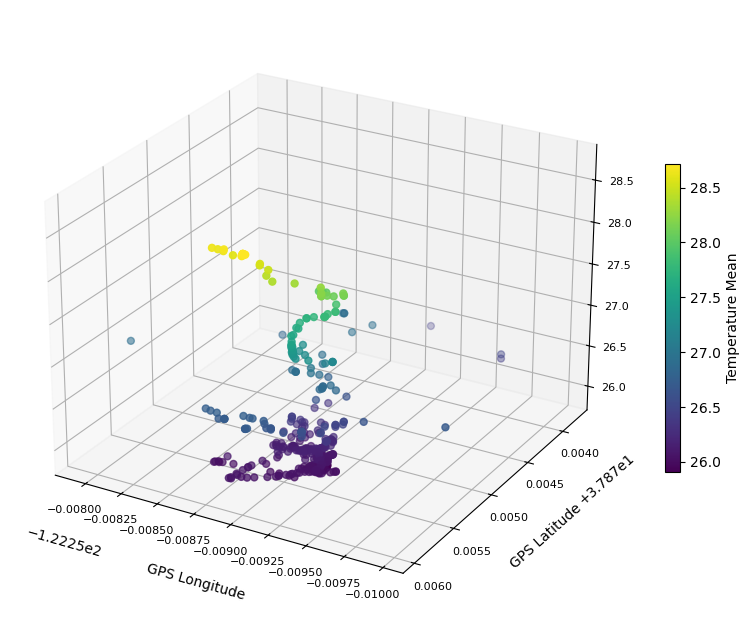

In [39]:
fig = plt.figure(figsize = (10,8))
ax = fig.add_subplot(111, projection = '3d')

scatter = ax.scatter(GPSPTH['longitude'], GPSPTH['latitude'], GPSPTH['temp_mean'], c = GPSPTH['temp_mean'], cmap = 'viridis', s = 25)
colorbar = plt.colorbar(scatter, label = 'Temperature Mean', shrink = 0.5)

ax.tick_params(axis = 'both', which = 'major', length = 2, width = 0.5, labelsize = 8)
ax.set_xlabel('GPS Longitude', labelpad = 10)
ax.set_ylabel('GPS Latitude', labelpad = 10)
#ax.set_zlabel('Temperature Mean', labelpad = 10)

ax.view_init(elev = 25, azim = 120)

#plt.title('Temperature Mean vs. Longitude and Latitude', fontsize = 20)
#plt.grid(alpha = 0.5)
plt.show()

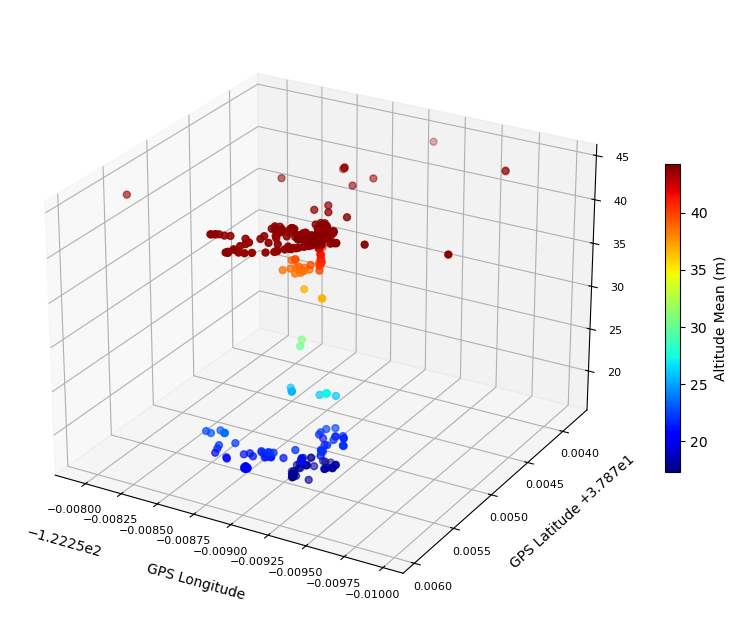

In [40]:
fig = plt.figure(figsize = (10,8))
ax = fig.add_subplot(111, projection = '3d')

scatter = ax.scatter(GPSPTH['longitude'], GPSPTH['latitude'], GPSPTH['alt_mean'], c = GPSPTH['alt_mean'], cmap = 'jet', s = 25)
colorbar = plt.colorbar(scatter, label = 'Altitude Mean (m)', shrink = 0.5)

ax.tick_params(axis = 'both', which = 'major', length = 2, width = 0.5, labelsize = 8)
ax.set_xlabel('GPS Longitude', labelpad = 10)
ax.set_ylabel('GPS Latitude', labelpad = 10)
#ax.set_zlabel('Temperature Mean', labelpad = 10)

ax.view_init(elev = 25, azim = 120)

#plt.title('Temperature Mean vs. Longitude and Latitude', fontsize = 20)
#plt.grid(alpha = 0.5)
plt.show()

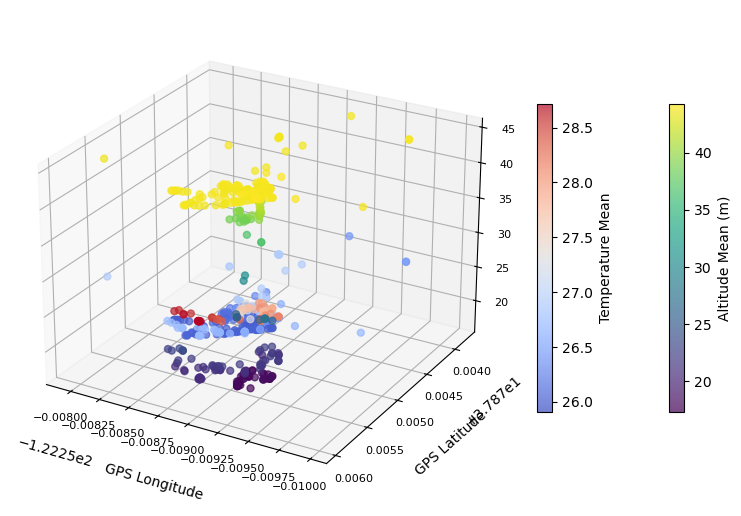

In [41]:
fig = plt.figure(figsize = (10,8))
ax = fig.add_subplot(111, projection = '3d')

scatter = ax.scatter(GPSPTH['longitude'], GPSPTH['latitude'], GPSPTH['alt_mean'], c = GPSPTH['alt_mean'], cmap = 'viridis', s = 25, alpha = 0.7)
colorbar = plt.colorbar(scatter, label = 'Altitude Mean (m)', shrink = 0.5)

scatter = ax.scatter(GPSPTH['longitude'], GPSPTH['latitude'], GPSPTH['temp_mean'], c = GPSPTH['temp_mean'], cmap = 'coolwarm', s = 25, alpha = 0.7)
colorbar = plt.colorbar(scatter, label = 'Temperature Mean', shrink = 0.5)

ax.tick_params(axis = 'both', which = 'major', length = 2, width = 0.5, labelsize = 8)
ax.set_xlabel('GPS Longitude', labelpad = 10)
ax.set_ylabel('GPS Latitude', labelpad = 10)
#ax.set_zlabel('Temperature Mean', labelpad = 10)

ax.view_init(elev = 25, azim = 120)

#plt.title('Temperature Mean vs. Longitude and Latitude', fontsize = 20)
#plt.grid(alpha = 0.5)
plt.show()

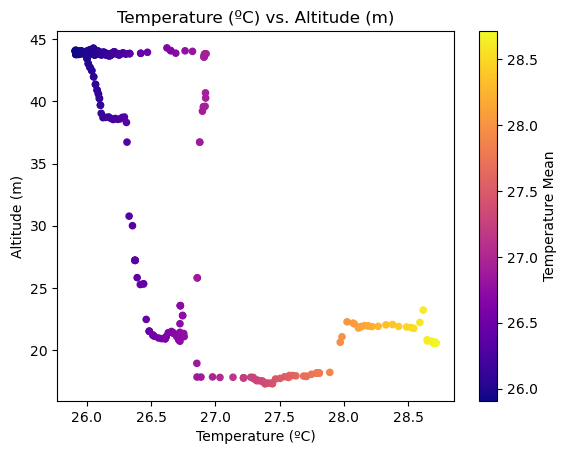

In [42]:
fig = plt.figure()
ax = plt.axes()

scatter = ax.scatter(GPSPTH['temp_mean'], GPSPTH['alt_mean'], c = GPSPTH['temp_mean'], cmap = 'plasma', s = 20)
colorbar = plt.colorbar(scatter, label = 'Temperature Mean')

ax.set_title('Temperature (ºC) vs. Altitude (m)')
ax.set_xlabel('Temperature (ºC)')
ax.set_ylabel('Altitude (m)')

plt.show()

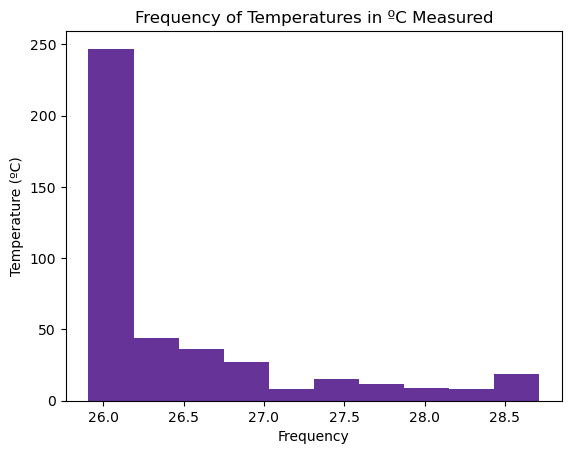

In [43]:
plt.figure()
ax = plt.axes()

counts, bins = np.histogram(GPSPTH['temp_mean'])
plt.hist(bins[:-1], bins, weights = counts, color = 'rebeccapurple')
ax.set_xlabel('Frequency')
ax.set_ylabel('Temperature (ºC)')
ax.set_title('Frequency of Temperatures in ºC Measured')

plt.show()

In [59]:
from scipy.stats import norm

tempMean = np.mean(GPSPTH['temp_mean'])
tempSTD = np.std(GPSPTH['temp_mean'])
tempMVar = GPSPTH['temp_mean'].var() #np.var(GPSPTH['temp_mean'])
tempExVar = tempSTD ** 2

print(f'The mean temperature throughout all 16 measurements = {tempMean} ºC and standard deviation = {tempSTD} ºC.')
print(f'The measured variance is {tempExVar} ºC and the expected variance is {tempExVar}, indicating they are the same.')

The mean temperature throughout all 16 measurements = 26.50719301470588 ºC and standard deviation = 0.7279499046854664 ºC.
The measured variance is 0.5299110637315796 ºC and the expected variance is 0.5299110637315796, indicating they are the same.


In [63]:
inAgreement = (tempSTD / len(GPSPTH['temp_mean'])) < tempSTD
inAgreement

np.True_